In [1]:
import matplotlib.pyplot as plt
import torch

from score.score import Score2d
from score.distributions import NoisyUniform2D, standard_gaussian_2d

In [2]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 128),
    torch.nn.Softplus(),
    torch.nn.Linear(128, 128),
    torch.nn.Softplus(),
    torch.nn.Linear(128, 2))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
score = Score2d(model, optimizer, NoisyUniform2D(noise_level=0.01))

In [3]:
loss, grad_norm = score.learn(
	n_samples_per_iter = 1000,
	n_iters = 1000,
	keep_best = True 
)

100%|██████████| 1000/1000 [00:11<00:00, 88.63it/s]


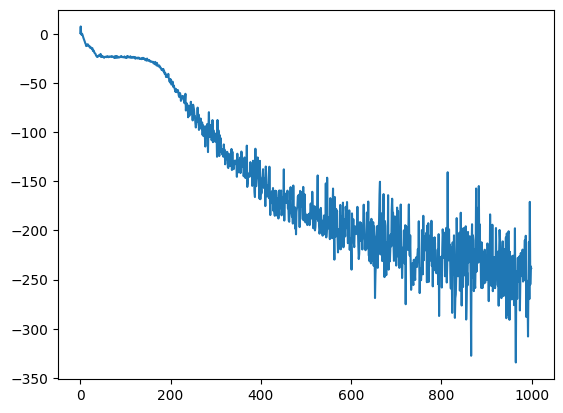

In [4]:
plt.plot(loss)

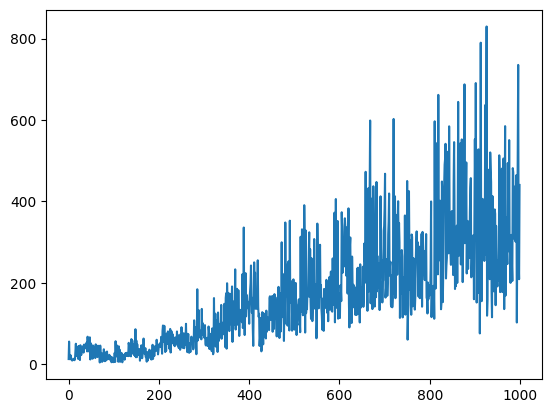

In [5]:
plt.plot(grad_norm)

/Users/qinyilong/Desktop/nn-score-matching/venv/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3527.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


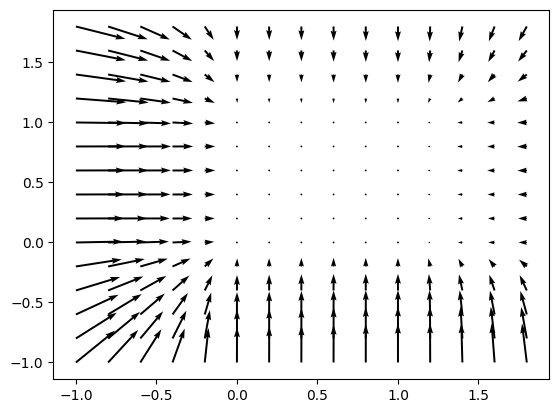

In [6]:
g, s = score.score_approx(-1, 2, -1, 2, 0.2)
g, s = g.numpy().T, s.numpy().T
plt.quiver(g[0], g[1], s[0], s[1])

In [7]:
init_samples = standard_gaussian_2d().sample((1000, ))
samples = score.sample_langevin(
	init_samples = init_samples,
	n_steps = 1000,
	epsilon = 0.1
)

100%|██████████| 1000/1000 [00:00<00:00, 1801.19it/s]


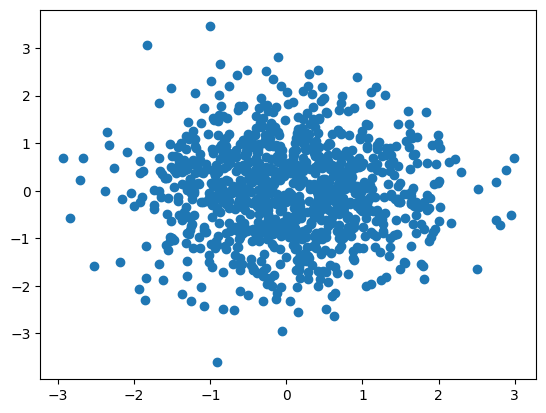

In [8]:
init_samples = init_samples.numpy().T
samples = samples.numpy().T
plt.scatter(init_samples[0], init_samples[1])
plt.scatter(samples[0], samples[1])